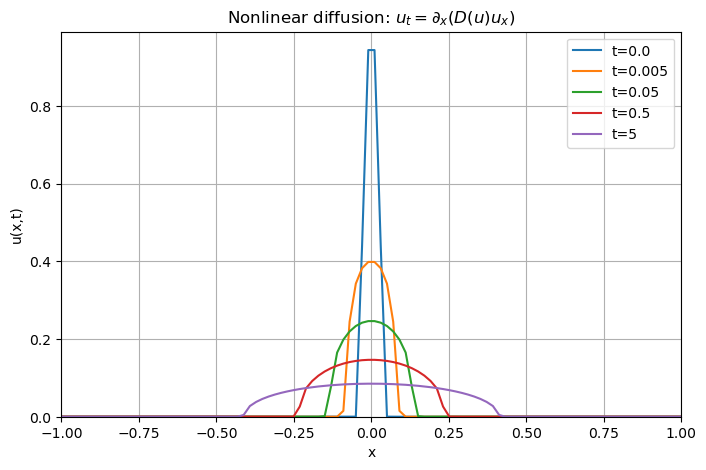

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 参数设置
# =========================
L = 2.0          # 空间区间 [-L, L]
Nx = 200         # 空间网格数
dx = 2 * L / Nx

T = 5.1          # 总时间
dt = 1e-6         # 时间步长
Nt = int(T / dt)

b = 2.0           # 扩散指数参数

# 绘图时刻
plot_times = [0.0, 0.005, 0.05, 0.5, 5]

# =========================
# 空间网格
# =========================
x = np.linspace(-L, L, Nx)

# =========================
# delta 初值的近似：
# 用窄高斯代替 delta(x)
# =========================
sigma = 0.01

u = np.exp(-x**2 / (2 * sigma**2))
u /= np.sum(u) * dx   # 归一化，使总质量≈1

# 为了避免 u 接近 1 导致发散
u = np.clip(u, 1e-12, 0.95)

# =========================
# 扩散系数
# =========================
def D(u):
    eps = 1e-10
    u = np.clip(u, eps, 1 - 1e-6)
    return (u**b) / ((1 - u)**b)

# =========================
# 保存结果
# =========================
saved = {}
current_time = 0.0

# =========================
# 时间推进（显式有限差分）
# =========================
for n in range(Nt):

    # 半点扩散系数
    u_mid_right = 0.5 * (u[1:] + u[:-1])
    D_mid = D(u_mid_right)

    # 通量
    flux = D_mid * (u[1:] - u[:-1]) / dx

    # 散度
    dudt = np.zeros_like(u)
    dudt[1:-1] = (flux[1:] - flux[:-1]) / dx

    # Neumann 边界（零通量）
    dudt[0] = 0
    dudt[-1] = 0

    # 更新
    u += dt * dudt

    # 保持非负并避免接近1
    u = np.clip(u, 1e-12, 0.999)

    current_time += dt

    # 保存指定时刻
    for pt in plot_times:
        if pt not in saved and current_time >= pt:
            saved[pt] = u.copy()

# =========================
# 绘图
# =========================
plt.figure(figsize=(8,5))

for pt in plot_times:
    plt.plot(x, saved[pt], label=f"t={pt}")

plt.xlim(-1, 1)
plt.ylim(bottom=0)

plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title(r"Nonlinear diffusion: $u_t=\partial_x(D(u)u_x)$")

plt.legend()
plt.grid(True)
plt.show()

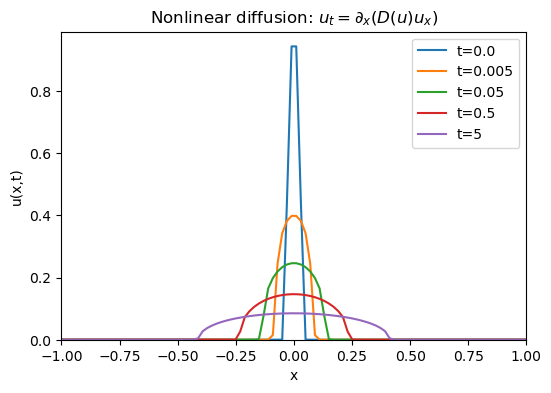

In [23]:
# =========================
# 绘图
# =========================
plt.figure(figsize=(6,4))

for pt in plot_times:
    plt.plot(x, saved[pt], label=f"t={pt}")

plt.xlim(-1, 1)
plt.ylim(bottom=0)

plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title(r"Nonlinear diffusion: $u_t=\partial_x(D(u)u_x)$")

plt.legend()
#plt.grid(True)
plt.show()

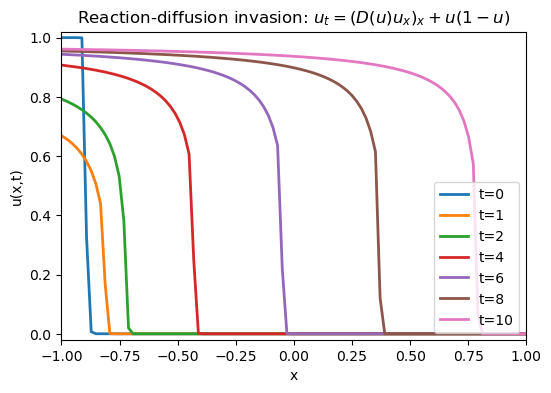

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# ==================================
# 参数
# ==================================
L = 5.0
Nx = 500

dx = 2 * L / Nx
x = np.linspace(-L, L, Nx)

T = 10.1
dt = 1e-5
Nt = int(T / dt)

b = 2.0

# 绘图时刻
plot_times = [0, 1, 2, 4, 6, 8, 10]

# ==================================
# 初值：左侧入侵
# u=1 (x<0)
# u=0 (x>0)
# 为避免数值震荡，做平滑
# ==================================
width = 0.01

u = (1 - np.tanh((x+0.9) / width))

# 避免严格到1
u = np.clip(u, 1e-8, 1 - 1e-6)

# ==================================
# 扩散系数
# ==================================
def D(u):
    eps = 1e-10
    u = np.clip(u, eps, 1 - 1e-8)
    return (u**b) / ((1 - u)**b)

# ==================================
# 保存结果
# ==================================
saved = {}

current_time = 0.0

# ==================================
# 时间推进
# ==================================
for n in range(Nt):

    # ---- 扩散项 ----
    u_mid = 0.5 * (u[1:] + u[:-1])
    D_mid = D(u_mid)

    flux = D_mid * (u[1:] - u[:-1]) / dx

    diffusion = np.zeros_like(u)
    diffusion[1:-1] = 0.01*(flux[1:] - flux[:-1]) / dx

    # Neumann 边界
    diffusion[0] = 0
    diffusion[-1] = 0

    # ---- 反应项 ----
    reaction = u * (1 - u)

    # ---- 更新 ----
    u += dt * (diffusion + reaction)

    # 保持稳定
    u = np.clip(u, 0, 1 - 1e-8)

    current_time += dt

    # 保存
    for pt in plot_times:
        if pt not in saved and current_time >= pt:
            saved[pt] = u.copy()

# ==================================
# 绘图
# ==================================
plt.figure(figsize=(6,4))

for pt in plot_times:
    plt.plot(x, saved[pt], lw=2, label=f"t={pt}")

plt.xlabel("x")
plt.ylabel("u(x,t)")

plt.title(
    r"Reaction-diffusion invasion: "
    r"$u_t=(D(u)u_x)_x+u(1-u)$"
)

plt.xlim(-1, 1)
plt.ylim(-0.02, 1.02)

#plt.grid(True)
plt.legend()

plt.show()